<a href="https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/Entornos_Complejos/monte_carlo_on_policy_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparación de algoritmos para el entorno Taxi de Gymnasium

## Liberias

In [1]:
import random
import numpy as np
import gymnasium as gym

from src.experiment import monte_carlo, sarsa, q_learning
from src.plotting import plot_episodes_lengths, plot_episodes_rewards, plot_episodes_epsilons, plot_policy_episodes

## Constantes

In [2]:
SEED = 42

N_EPISODES = 500_000
DISCOUNT_FACTOR = 0.99
ALPHA = 0.1

EPSILON_MAX = 0.5
EPSILON_MIN = 0.05
EPSILON_DECAY_SLOWDOWN = 5

N_EPISODES_SHOW = 1
PLOT_MA_WINDOW = 1000

## Reproducibilidad

In [3]:
random.seed(SEED)
np.random.seed(SEED)

## El entorno Taxi

### Espacio de acciones

In [4]:
ACTIONS = set(range(0, 6))
print("Actions:", ACTIONS)

Actions: {0, 1, 2, 3, 4, 5}


### Espacio de observaciones

In [5]:
PASSENGER_LOCATIONS = set(range(0,5))
DESTINATIONS = set(range(0,4))

print("Passenger locations:", PASSENGER_LOCATIONS)
print("Destinations:", DESTINATIONS)

Passenger locations: {0, 1, 2, 3, 4}
Destinations: {0, 1, 2, 3}


## Experimentación

In [6]:
env = gym.make("Taxi-v4")
ON_POLICY = True
Q_on, episodes_rewards_on, episode_lengths_off, _ = monte_carlo(env, ON_POLICY, N_EPISODES, DISCOUNT_FACTOR, EPSILON_MAX, EPSILON_MIN, EPSILON_DECAY_SLOWDOWN, SEED)

 10%|█         | 50175/500000 [01:12<05:45, 1301.07it/s] 

progress 10.0% | mean reward: -75.51214975700486, epsilon: 0.33495819242123137


 20%|██        | 100141/500000 [01:57<04:30, 1480.17it/s]

progress 20.0% | mean reward: -47.039549604503954, epsilon: 0.22439398134019728


 30%|███       | 150206/500000 [02:33<03:35, 1626.14it/s]

...

progress 80.0% | mean reward: -13.078577303556742, epsilon: 0.05


 90%|█████████ | 450175/500000 [05:43<00:28, 1720.17it/s]

progress 90.0% | mean reward: -11.472343394792455, epsilon: 0.05


100%|██████████| 500000/500000 [06:14<00:00, 1335.16it/s]

progress 99.99980000000001% | mean reward: -10.19298, epsilon: 0.05


In [7]:
env = gym.make("Taxi-v4")
ON_POLICY = False
Q_off, episodes_rewards_off, episode_lengths_off, _ = monte_carlo(env, ON_POLICY, N_EPISODES, DISCOUNT_FACTOR, EPSILON_MAX, EPSILON_MIN, EPSILON_DECAY_SLOWDOWN, SEED)

 10%|█         | 50124/500000 [01:59<06:46, 1107.04it/s] 

progress 10.0% | mean reward: -172.992500149997, epsilon: 0.33495819242123137


 20%|██        | 100189/500000 [02:36<03:50, 1736.83it/s]

progress 20.0% | mean reward: -96.6139638603614, epsilon: 0.22439398134019728


 30%|███       | 150269/500000 [03:07<03:03, 1908.24it/s]

...

progress 80.0% | mean reward: -22.99543251141872, epsilon: 0.05


 90%|█████████ | 450265/500000 [05:42<00:25, 1955.32it/s]

progress 90.0% | mean reward: -19.89688911802418, epsilon: 0.05


100%|██████████| 500000/500000 [06:04<00:00, 1370.14it/s]

progress 99.99980000000001% | mean reward: -17.420142, epsilon: 0.05


In [10]:
env = gym.make("Taxi-v4")
Q_sarsa, episodes_rewards_sarsa, episode_lengths_sarsa, _ = sarsa(env, N_EPISODES, DISCOUNT_FACTOR, ALPHA, EPSILON_MAX, EPSILON_MIN, EPSILON_DECAY_SLOWDOWN, SEED)

 10%|█         | 50262/500000 [00:52<05:21, 1396.71it/s]

progress 10.0% | mean reward: -41.638787224255516, epsilon: 0.33495819242123137


 20%|██        | 100355/500000 [01:26<03:54, 1703.48it/s]

progress 20.0% | mean reward: -26.789552104478954, epsilon: 0.22439398134019728


 30%|███       | 150237/500000 [01:57<03:48, 1531.87it/s]

...

progress 80.0% | mean reward: -4.712133219666951, epsilon: 0.05


 90%|█████████ | 450411/500000 [04:34<00:23, 2135.50it/s]

progress 90.0% | mean reward: -3.6075164277412717, epsilon: 0.05


100%|██████████| 500000/500000 [04:58<00:00, 1673.05it/s]

progress 99.99980000000001% | mean reward: -2.718046, epsilon: 0.05


In [11]:
env = gym.make("Taxi-v4")
Q_ql, episodes_rewards_ql, episode_lengths_ql, _ = q_learning(env, N_EPISODES, DISCOUNT_FACTOR, ALPHA, EPSILON_MAX, EPSILON_MIN, EPSILON_DECAY_SLOWDOWN, SEED)

 10%|█         | 50219/500000 [00:55<06:03, 1236.89it/s] 

progress 10.0% | mean reward: -34.16417671646567, epsilon: 0.33495819242123137


 20%|██        | 100140/500000 [01:39<05:48, 1147.41it/s]

progress 20.0% | mean reward: -22.916920830791693, epsilon: 0.22439398134019728


 30%|███       | 150211/500000 [02:16<03:48, 1532.92it/s]

...

progress 80.0% | mean reward: -3.6907732730668172, epsilon: 0.05


 90%|█████████ | 450319/500000 [05:30<00:36, 1376.03it/s]

progress 90.0% | mean reward: -2.6886451363441415, epsilon: 0.05


100%|██████████| 500000/500000 [06:02<00:00, 1377.67it/s]

progress 99.99980000000001% | mean reward: -1.884054, epsilon: 0.05


### Evaluación

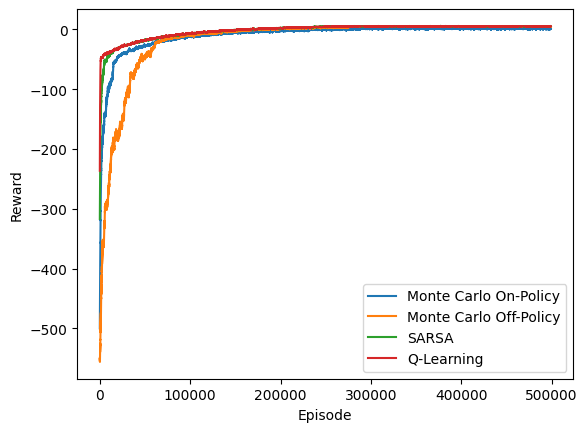

In [13]:
plot_episodes_rewards(
    [
        (episodes_rewards_on, "Monte Carlo On-Policy"),
        (episodes_rewards_off, "Monte Carlo Off-Policy"),
        (episodes_rewards_sarsa, "SARSA"),
        (episodes_rewards_ql, "Q-Learning"),
    ], 
    PLOT_MA_WINDOW
)